# Credit Card Fraud Detection

Single notebook: EDA → Preprocessing → SMOTE → PCA (optional) → Train & Compare LogisticRegression + RandomForest → Evaluate → Save model → Inference

Dataset: `creditcard.csv` (place in `data/raw/creditcard.csv`)

In [1]:
# Imports & settings
import os
import numpy as np # type: ignore
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore
from sklearn.model_selection import train_test_split, GridSearchCV # type: ignore
from sklearn.preprocessing import StandardScaler # type: ignore
from sklearn.decomposition import PCA # type: ignore # type: ignore
from sklearn.linear_model import LogisticRegression # type: ignore
from sklearn.ensemble import RandomForestClassifier # type: ignore
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay # type: ignore
from imblearn.over_sampling import SMOTE # type: ignore
import joblib # type: ignore

# display settings
%matplotlib inline
sns.set(style='whitegrid')

DATA_RAW = os.path.join('data','raw','creditcard.csv')
PROCESSED = os.path.join('data','processed')
os.makedirs(PROCESSED, exist_ok=True)

In [11]:
import os
import pandas as pd

DATA_RAW = "../data/raw/creditcard.csv"   # go one level up

if not os.path.exists(DATA_RAW):
    raise FileNotFoundError(
        f"File not found: {DATA_RAW}\n"
        f"Looking here: {os.path.abspath(DATA_RAW)}"
    )

df = pd.read_csv(DATA_RAW)

print("Shape:", df.shape)
print(df.columns.tolist())

df.head()

Shape: (284807, 31)
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [12]:
print(df.info())
print('\nMissing values per column:\n', df.isnull().sum())
print('\nClass distribution:\n', df['Class'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

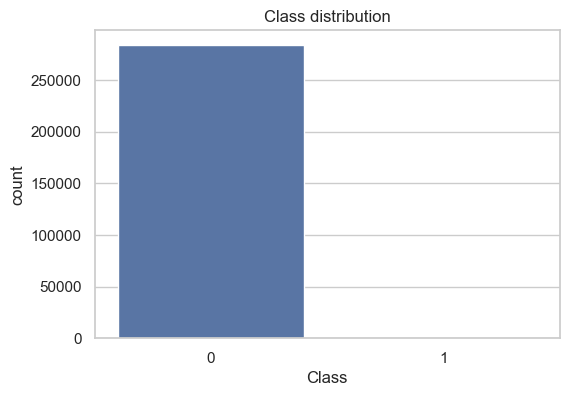

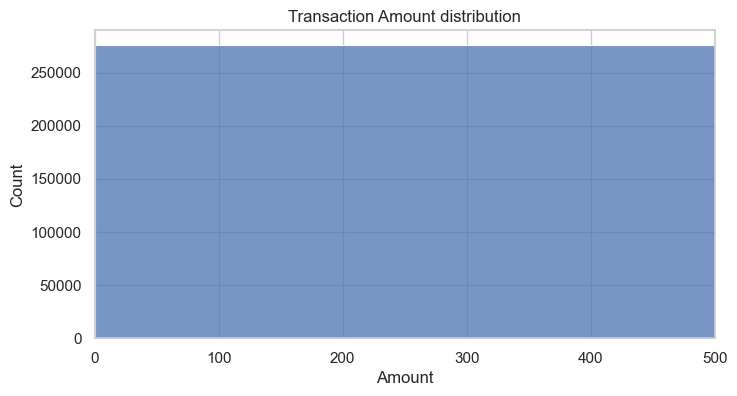

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class distribution')
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(df['Amount'], bins=50)
plt.title('Transaction Amount distribution')
plt.xlim(0, 500)
plt.show()

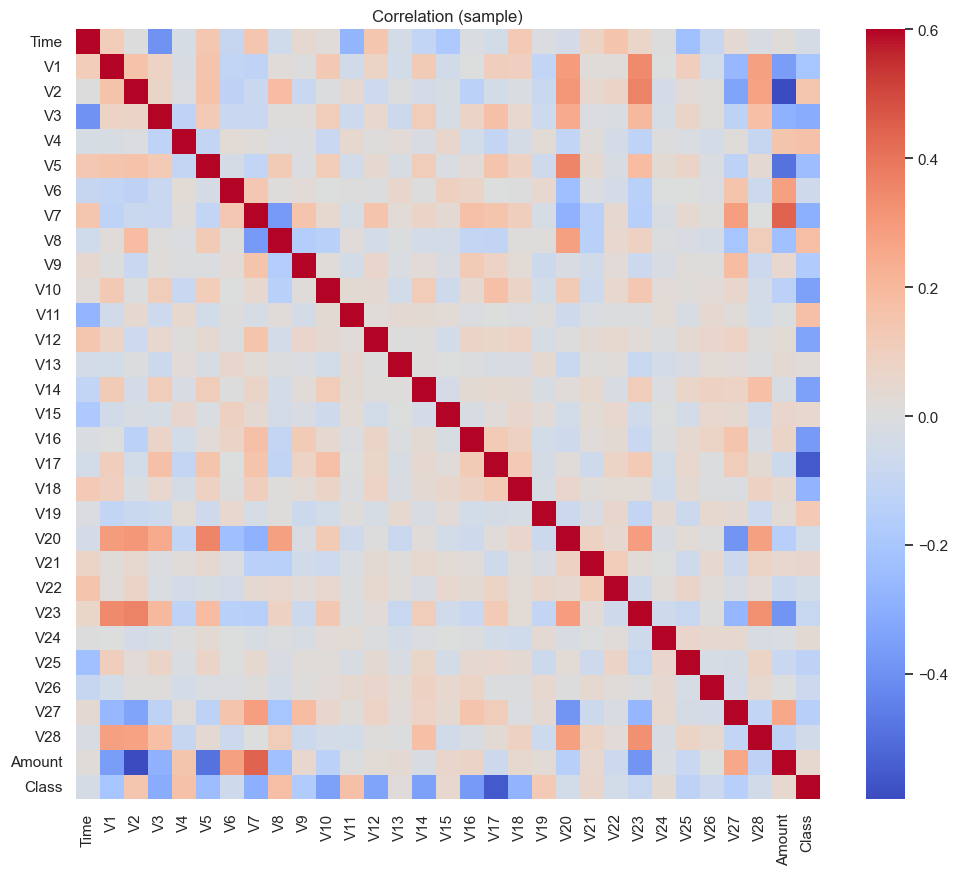

In [14]:
sample = df.sample(1000, random_state=42)
plt.figure(figsize=(12,10))
sns.heatmap(sample.corr(), cmap='coolwarm', vmax=0.6)
plt.title('Correlation (sample)')
plt.show()

In [15]:
X = df.drop(columns=['Class'])
y = df['Class']

scaler = StandardScaler()
X[['Time','Amount']] = scaler.fit_transform(X[['Time','Amount']])

scaled_path = os.path.join(PROCESSED, 'creditcard_scaled.csv')
pd.concat([X, y], axis=1).to_csv(scaled_path, index=False)
print('Saved scaled data to', scaled_path)

Saved scaled data to data/processed/creditcard_scaled.csv


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Train shape: (227845, 30) Test shape: (56962, 30)


In [17]:
print('Before SMOTE:', np.bincount(y_train))
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print('After SMOTE:', np.bincount(y_train_res))

Before SMOTE: [227451    394]
After SMOTE: [227451 227451]


In [18]:
use_pca = False
if use_pca:
    pca = PCA(n_components=20, random_state=42)
    X_train_res = pca.fit_transform(X_train_res)
    X_test_pca = pca.transform(X_test)
    print('Explained variance:', pca.explained_variance_ratio_.sum())
else:
    X_test_pca = X_test.values

In [19]:
X_train_fit = X_train_res
X_test_fit = X_test_pca if use_pca else X_test

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr_params = {'C':[0.01, 0.1, 1.0]}
lr_grid = GridSearchCV(lr, lr_params, cv=3, scoring='f1', n_jobs=-1, verbose=1)
lr_grid.fit(X_train_fit, y_train_res)
print('LR best:', lr_grid.best_params_)

# Random Forest
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_params = {'n_estimators':[100], 'max_depth':[8]}
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='f1', n_jobs=-1, verbose=1)
rf_grid.fit(X_train_fit, y_train_res)
print('RF best:', rf_grid.best_params_)

best_lr = lr_grid.best_estimator_
best_rf = rf_grid.best_estimator_

Fitting 3 folds for each of 3 candidates, totalling 9 fits
LR best: {'C': 1.0}
Fitting 3 folds for each of 1 candidates, totalling 3 fits
RF best: {'max_depth': 8, 'n_estimators': 100}


--- LogisticRegression ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9698482164390798
Confusion matrix:
 [[55406  1458]
 [    8    90]]


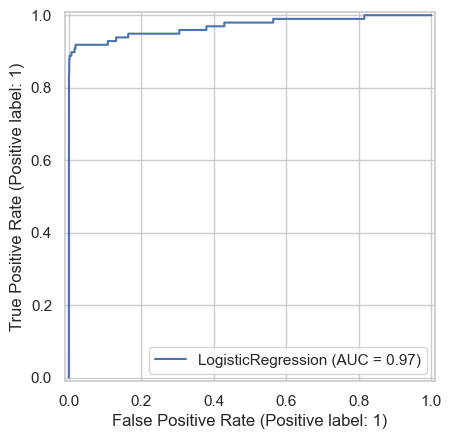

--- RandomForest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.32      0.89      0.47        98

    accuracy                           1.00     56962
   macro avg       0.66      0.94      0.73     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9781160635328977
Confusion matrix:
 [[56675   189]
 [   11    87]]


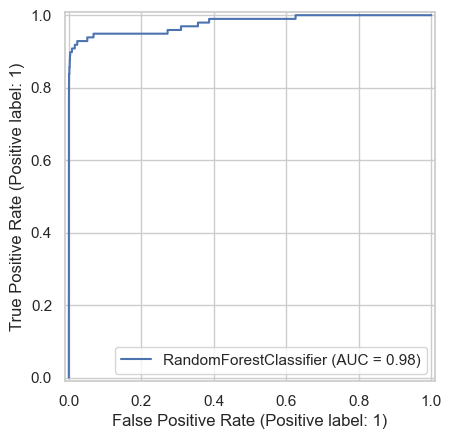

In [20]:
for name, model in [('LogisticRegression', best_lr), ('RandomForest', best_rf)]:
    preds = model.predict(X_test_fit)
    proba = model.predict_proba(X_test_fit)[:,1]
    print(f"--- {name} ---")
    print(classification_report(y_test, preds))
    print('ROC-AUC:', roc_auc_score(y_test, proba))
    print('Confusion matrix:\n', confusion_matrix(y_test, preds))
    RocCurveDisplay.from_estimator(model, X_test_fit, y_test)
    plt.show()

In [22]:
pca_obj = pca if use_pca else None

best_model = best_rf

os.makedirs('models', exist_ok=True)

model_path = os.path.join('models', 'fraud_model.joblib')

joblib.dump({
    'model': best_model,
    'scaler': scaler,
    'use_pca': use_pca,
    'pca': pca_obj
}, model_path)

print('Saved model to', model_path)

Saved model to models/fraud_model.joblib


In [23]:
saved = joblib.load(model_path)
model = saved['model']
loaded_scaler = saved['scaler']
use_pca_loaded = saved['use_pca']
pca_loaded = saved['pca']

sample = X_test.iloc[[0]].copy()
sample[['Time','Amount']] = loaded_scaler.transform(sample[['Time','Amount']])

if use_pca_loaded:
    sample_arr = pca_loaded.transform(sample.values)
else:
    sample_arr = sample.values

pred = model.predict(sample_arr)[0]
proba = model.predict_proba(sample_arr)[0,1]
print('Prediction:', pred)
print('Fraud probability:', proba)

Prediction: 0
Fraud probability: 0.036406214209934805


/Users/karthikchaitanya/Documents/projects/credit-card-fraud-project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/karthikchaitanya/Documents/projects/credit-card-fraud-project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
